In [3]:
import requests
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment

In [4]:
df = pd.read_csv('news_AP.csv')
df

,title,topic
0,Terminally ill Connecticut woman ends her life...,Healthcare
1,King Charles III will have a prostate operatio...,Healthcare
2,Community health centers serve 1 in 11 America...,Healthcare
3,Washington state reaches a nearly $150 million...,Healthcare
4,Community health centers serve 1 in 11 America...,Healthcare
...,...,...
194,No joke: Feds discourage humorous electronic m...,Transportation
195,A timeline of key moments leading to Japan pla...,Transportation
196,Federal officials order grounding of some Boei...,Transportation
197,What you should know if you're about to fly on...,Transportation


### Preprocess text

In [5]:
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources (run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Remove duplicate titles
df = df.drop_duplicates(subset='title').reset_index(drop=True)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess(text):
    tokens = word_tokenize(text)

    cleaned_tokens = []
    for token in tokens:
        if token == "US":
            cleaned_tokens.append("us")  # preserve as meaningful token
        else:
            token_lower = token.lower()
            if (
                token_lower not in stop_words and
                token_lower not in string.punctuation and
                token_lower != "'s"
            ):
                cleaned_tokens.append(lemmatizer.lemmatize(token_lower))

    return " ".join(cleaned_tokens)

# Apply to titles
df['cleaned'] = df['title'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hartejhs/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/hartejhs/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/hartejhs/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/hartejhs/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
df

,title,topic,cleaned
0,Terminally ill Connecticut woman ends her life...,Healthcare,terminally ill connecticut woman end life term...
1,King Charles III will have a prostate operatio...,Healthcare,king charles iii prostate operation next week ...
2,Community health centers serve 1 in 11 America...,Healthcare,community health center serve 1 11 american 'r...
3,Washington state reaches a nearly $150 million...,Healthcare,washington state reach nearly 150 million sett...
4,Defense Secretary Lloyd Austin returns to work...,Healthcare,defense secretary lloyd austin return work pen...
...,...,...,...
148,US officials say 40 Boeing jets have been insp...,Transportation,us official say 40 boeing jet inspected invest...
149,A timeline of key moments leading to Japan pla...,Transportation,timeline key moment leading japan plane collid...
150,Federal officials order grounding of some Boei...,Transportation,federal official order grounding boeing 737 ma...
151,What you should know if you're about to fly on...,Transportation,know 're fly boeing max 9


The dataset originally contained 199 news headlines and two columns: title and topic. After removing 46 exact duplicate titles, 153 entries remained. This step was included to ensure that each document represented a distinct observation, preventing artificial clustering bias. The dataset shows a clear class imbalance, with Sports – Football comprising the majority of headlines (73), followed by Transportation (31), Animals (30), and Healthcare (19). There are no missing values in the data set, so there wasn’t a need to drop/impute any data. The text data was then preprocessed using NLTK through several steps, including lowercasing, tokenization, removal of stopwords, punctuation filtering, and lemmatization. Possessive fragments like "'s" were removed, as they carry little semantic value and might introduce noise during vectorization. Special handling was applied to preserve the term "US," which is often misinterpreted as the pronoun "us" and removed by default. Since "US" frequently appeared in headlines as a reference to the United States, and the pronoun "us" was not used in headlines, it made sense to retain the term for accurate topic representation. The following function was used to preprocess the text:


### Vectorize:

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = df['cleaned'].tolist()
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(corpus)

In [18]:
# Convert to DataFrame for inspection
dtm_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
dtm_df

,000,10,11,12,13,14,150,17,18,1st,...,work,working,world,wr,yard,year,york,young,zebra,zoo
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.327571,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.292008,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.364877,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
149,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
151,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
from sentence_transformers import SentenceTransformer
import pandas as pd

# Use original sentence data (no heavy preprocessing!)
documents = df['title'].tolist()

# Load SBERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate dense sentence/document embeddings
X_sbert = model.encode(documents)

# Convert to DataFrame for inspection
sbert_df = pd.DataFrame(X_sbert, columns=[f'sbert_{i}' for i in range(X_sbert.shape[1])])

In [22]:
sbert_df

,sbert_0,sbert_1,sbert_2,sbert_3,sbert_4,sbert_5,sbert_6,sbert_7,sbert_8,sbert_9,...,sbert_374,sbert_375,sbert_376,sbert_377,sbert_378,sbert_379,sbert_380,sbert_381,sbert_382,sbert_383
0,-0.024464,-0.014333,0.044128,-0.011013,0.025188,0.050360,-0.070752,0.017109,-0.010366,0.086726,...,0.000695,0.018939,0.007736,0.073958,-0.054916,0.084840,-0.033781,-0.026217,0.025913,-0.070086
1,-0.073512,-0.016917,0.004738,0.004698,-0.073170,0.027185,-0.062438,-0.019510,0.029975,0.010623,...,0.052889,0.043730,0.026666,-0.023316,0.045433,0.081220,0.063280,-0.085793,-0.026191,0.055879
2,0.064699,-0.071363,-0.050958,0.055113,-0.007008,0.048815,0.010984,-0.022630,-0.057572,-0.009141,...,0.012730,-0.016899,-0.000630,0.006292,0.008525,0.014190,-0.041465,-0.019446,-0.002284,0.015086
3,0.000114,0.045588,0.021821,0.080863,-0.031234,-0.019093,-0.019616,0.089973,0.009219,0.030130,...,0.004556,-0.041212,-0.016274,0.023711,-0.030276,-0.050503,-0.078725,-0.073335,0.015673,0.000375
4,-0.017300,0.002479,0.098149,0.025859,-0.026914,-0.005498,-0.008851,-0.044598,0.007633,-0.039643,...,-0.006805,0.027773,0.032041,0.018508,-0.060855,0.015424,-0.113837,-0.057756,0.075038,0.013442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,0.045440,0.000461,0.025066,0.040130,0.066220,-0.007982,-0.025446,0.007625,-0.029326,0.018092,...,-0.039076,0.067203,-0.004395,-0.005554,0.053743,-0.040002,-0.018017,-0.032320,0.003794,-0.025359
149,-0.003405,0.019211,0.048306,0.044726,0.059582,-0.024538,-0.006193,0.074481,0.021082,0.055232,...,0.023934,0.070492,0.014231,-0.071946,0.007553,0.048906,0.045905,0.030843,-0.103353,0.015913
150,0.040515,-0.032719,0.088101,0.027746,-0.051598,0.001448,-0.045018,0.078878,-0.011469,-0.026201,...,0.028791,0.023166,-0.056573,0.080714,0.031663,0.037633,-0.073971,-0.055441,0.022951,0.034801
151,0.054298,-0.058533,-0.018778,0.013875,0.032660,0.084155,-0.006498,0.047180,-0.133335,-0.029769,...,0.019737,0.012618,-0.045612,0.081673,-0.050632,0.064610,0.094234,-0.032228,-0.120209,-0.001212


To prepare the labels for classification, topic names were converted into integer values using LabelEncoder, producing a numerical target y used for supervised learning.
To train and evaluate the model, the dataset was divided into training and testing sets using an 80/20 stratified split, ensuring that the class proportions remained consistent across both subsets. A random_state of 42 was set to guarantee reproducibility of the split, allowing results to remain consistent across multiple iterations.


Two different approaches were used to convert the headlines into numerical representations. TF-IDF vectorization was applied to the preprocessed text, resulting in a 153 x 957 document-term matrix. Rather than simply counting word frequency, TF-IDF applies a weighting scheme that helps highlight distinctive vocabulary while downplaying common words. In contrast, a pre-trained sentence embedding model (all-MiniLM-L6-v2 from the sentence-transformers library) was used to generate dense 384 dimensional vectors that encode sentence-level meaning by considering the surrounding context of each word. The stark difference in dimensionality highlights the trade-off: while TF-IDF offers interpretable word based features, dense vectorization provides more compact, context-aware embeddings. To preserve this context, the original headlines were passed directly into the embedding model without preprocessing.


To optimize model performance, a 5-fold cross-validation loop was conducted on the training set to tune two key Random Forest hyperparameters: the number of trees (n_estimators) and the maximum depth of each tree (max_depth). In each fold, the model was trained on 80% of the training data and validated on the remaining 20%, with performance measured using the weighted F1-score to account for class imbalance. A RandomForestClassifier from sklearn.ensemble was utilized inside the tune_rf() function, trained on oversampled data, and evaluated across each fold. Random Forest is an ensemble learning method that combines multiple decision trees trained on random subsets of the data to improve prediction accuracy and control overfitting. The model with the highest average macro-F1 was stored and used for final testing. Using 5 folds instead of 3 offers a more stable estimate of model performance, especially with a dataset size of 150 samples. With 5-fold CV, each model is trained on 120 samples and validated on 30, allowing for better generalization while keeping computation reasonable.


To address class imbalance during training, random oversampling was applied within each fold using RandomOverSampler from the imbalanced-learn library. This technique duplicates examples from underrepresented classes in the training set, helping the model learn more balanced decision boundaries. Oversampling was limited to the training data to ensure that validation results remained unbiased. This step was particularly important given the overrepresentation of the Sports – Football topic, which likely could have influenced predictions negatively. The hyperparameter combination that yielded the highest average F1-score across folds was selected as the best configuration. This tuning process was conducted separately for both the TF-IDF and sentence embedding representations to ensure a fair comparison between the two feature types.


In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Assuming df is already loaded and contains 'title', 'cleaned', and 'topic' columns

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['topic'])
labels = le.classes_  # For named outputs

y = df['label'].values

# === Your existing vectorizations ===
# X_tfidf = ...
# X_sbert = ...

# 1) 80/20 split
X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42
)
X_sbert_train, X_sbert_test, _, _ = train_test_split(
    X_sbert, y, test_size=0.2, stratify=y, random_state=42
)

# helper for CV tuning
def tune_rf(X, y, n_folds=3, estimators=[100,200], depths=[None,8,4]):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=1)
    best = {'f1':0}
    for n in estimators:
        for d in depths:
            scores = []
            for tr, val in skf.split(X, y):
                model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
                model.fit(X[tr], y[tr])
                preds = model.predict(X[val])
                f1 = precision_recall_fscore_support(y[val], preds, average='macro', zero_division=0)[2]
                scores.append(f1)
            avg = np.mean(scores)
            if avg > best['f1']:
                best = {'f1':avg, 'n':n, 'd':d, 'model':model}
    return best

# 2) Tune on TF-IDF
tfidf_train_array = X_tfidf_train.toarray()
tfidf_test_array  = X_tfidf_test.toarray()
best_tfidf = tune_rf(tfidf_train_array, y_train, n_folds=5)
print("TF-IDF CV→", best_tfidf['f1'], best_tfidf['n'], best_tfidf['d'])

# 3) Final TF-IDF eval
y_tf = best_tfidf['model'].predict(tfidf_test_array)
print("TF-IDF Test Report\n", classification_report(y_test, y_tf, target_names=labels, zero_division=0))
print("TF-IDF Acc:", accuracy_score(y_test, y_tf))

# 4) Top-10 TF-IDF words
importances = best_tfidf['model'].feature_importances_
idx = np.argsort(importances)[-10:]
print("Top 10 TF-IDF features:", vectorizer.get_feature_names_out()[idx])

# 5) Tune on SBERT
best_sbert = tune_rf(X_sbert_train, y_train, n_folds=5)
print("SBERT CV→", best_sbert['f1'], best_sbert['n'], best_sbert['d'])

# 6) Final SBERT eval
y_sb = best_sbert['model'].predict(X_sbert_test)
print("SBERT Test Report\n", classification_report(y_test, y_sb, target_names=labels, zero_division=0))
print("SBERT Acc:", accuracy_score(y_test, y_sb))


TF-IDF CV→ 0.43306133474895336 200 None
TF-IDF Test Report
                    precision    recall  f1-score   support

          Animals       0.00      0.00      0.00         6
       Healthcare       1.00      0.50      0.67         4
Sports - Football       0.52      1.00      0.68        15
   Transportation       0.00      0.00      0.00         6

         accuracy                           0.55        31
        macro avg       0.38      0.38      0.34        31
     weighted avg       0.38      0.55      0.42        31

TF-IDF Acc: 0.5483870967741935
Top 10 TF-IDF features: ['trip' 'tied' 'model' 'decision' 'climate' 'dog' 'mccormick' 'au' 'jfk'
 'blast']
SBERT CV→ 0.8067649572649573 100 4
SBERT Test Report
                    precision    recall  f1-score   support

          Animals       1.00      0.83      0.91         6
       Healthcare       1.00      0.75      0.86         4
Sports - Football       0.83      1.00      0.91        15
   Transportation       1.00      0.

In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# 0. Assume df, X_tfidf, X_sbert already defined, and df['label'] exists

# For debugging: check your train/test label distribution
print("Train label counts:\n", pd.Series(y_train).value_counts())
print("Test  label counts:\n", pd.Series(y_test).value_counts())

# 1) 80/20 split
X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.2, stratify=df['label'], random_state=42
)
X_sbert_train, X_sbert_test, _, _ = train_test_split(
    X_sbert, df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

# Convert TF-IDF to dense arrays for RandomForest
X_tfidf_train_arr = X_tfidf_train.toarray()
X_tfidf_test_arr  = X_tfidf_test.toarray()

# 2) CV-tuning with balanced weights
def tune_rf(X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    best = {'f1': -1}
    for n in [100, 200]:
        for d in [None, 8, 4]:
            scores = []
            for tr, val in skf.split(X, y):
                rf = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=d,
                    class_weight='balanced',   # <<-- KEY CHANGE
                    random_state=42
                )
                rf.fit(X[tr], y[tr])
                yv = rf.predict(X[val])
                f1 = precision_recall_fscore_support(
                    y[val], yv, average='macro', zero_division=0
                )[2]
                scores.append(f1)
            avg = np.mean(scores)
            if avg > best['f1']:
                best = {'f1': avg, 'model': rf, 'n': n, 'd': d}
    return best

# Tune + evaluate TF-IDF
best_tfidf = tune_rf(X_tfidf_train_arr, y_train)
print("TF-IDF best CV macro-F1:", best_tfidf['f1'], "params:", best_tfidf['n'], best_tfidf['d'])

y_pred_tfidf = best_tfidf['model'].predict(X_tfidf_test_arr)
print("TF-IDF Test Report:\n",
      classification_report(y_test, y_pred_tfidf, target_names=le.classes_, zero_division=0))
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))

# Top-10 TF-IDF features
imps = best_tfidf['model'].feature_importances_
top10 = np.argsort(imps)[-10:]
print("Top 10 TF-IDF words:", vectorizer.get_feature_names_out()[top10])

# Tune + evaluate SBERT (already dense)
best_sbert = tune_rf(X_sbert_train, y_train)
print("SBERT best CV macro-F1:", best_sbert['f1'], "params:", best_sbert['n'], best_sbert['d'])

y_pred_sbert = best_sbert['model'].predict(X_sbert_test)
print("SBERT Test Report:\n",
      classification_report(y_test, y_pred_sbert, target_names=le.classes_, zero_division=0))
print("SBERT Accuracy:", accuracy_score(y_test, y_pred_sbert))


Train label counts:
 2    58
3    25
0    24
1    15
Name: count, dtype: int64
Test  label counts:
 2    15
3     6
0     6
1     4
Name: count, dtype: int64


KeyError: '[13, 14, 20, 22, 26, 27, 32, 35, 53, 54, 62, 65, 71, 78, 89, 90, 98, 102, 106, 111] not in index'


TF-IDF CV macro-F1: 0.7344466885771233 ; params: 100 8

TF-IDF TEST REPORT:
                    precision    recall  f1-score   support

          Animals       0.40      1.00      0.57         6
       Healthcare       1.00      0.50      0.67         4
Sports - Football       1.00      0.73      0.85        15
   Transportation       1.00      0.50      0.67         6

         accuracy                           0.71        31
        macro avg       0.85      0.68      0.69        31
     weighted avg       0.88      0.71      0.74        31

TF-IDF TEST ACCURACY: 0.7096774193548387


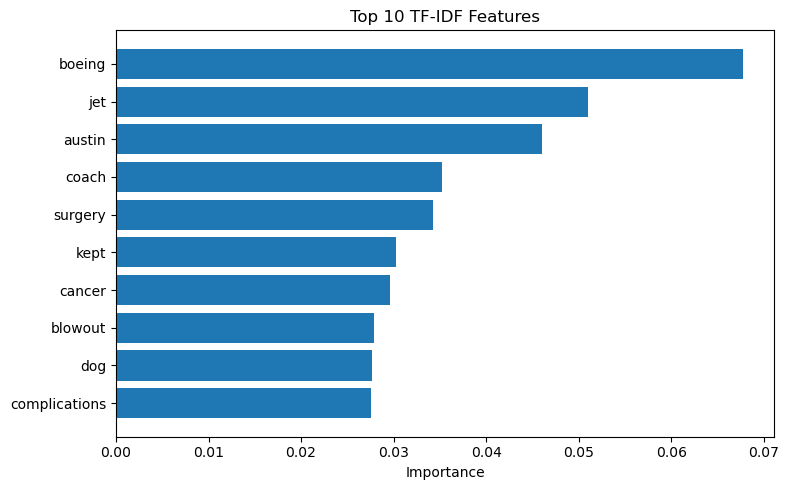


SBERT CV macro-F1: 0.9194046991655688 ; params: 200 4

SBERT TEST REPORT:
                    precision    recall  f1-score   support

          Animals       0.83      0.83      0.83         6
       Healthcare       1.00      1.00      1.00         4
Sports - Football       0.88      1.00      0.94        15
   Transportation       1.00      0.67      0.80         6

         accuracy                           0.90        31
        macro avg       0.93      0.88      0.89        31
     weighted avg       0.91      0.90      0.90        31

SBERT TEST ACCURACY: 0.9032258064516129


In [52]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

# 1) LOAD & LABEL-ENCODE
df = pd.read_csv('news_AP.csv').drop_duplicates(subset='title').reset_index(drop=True)
le = LabelEncoder()
y = le.fit_transform(df['topic'].values)   # integer labels 0…3
labels = le.classes_                       # e.g. ["Animals","Healthcare",...]

# 2) VECTORIZE
df['cleaned'] = df['title'].str.lower()
# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', min_df=2)
X_tfidf = vectorizer.fit_transform(df['cleaned'])
# SBERT
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_sbert = sbert_model.encode(df['title'].tolist())

# 3) 80/20 STRATIFIED SPLIT
X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(
    X_tfidf.toarray(), y, test_size=0.2, stratify=y, random_state=42
)
X_sbert_train, X_sbert_test, _, _ = train_test_split(
    X_sbert, y, test_size=0.2, stratify=y, random_state=42
)

# 4) TUNING FUNCTION WITH OVERSAMPLING ONLY ON TRAIN FOLD
ros = RandomOverSampler(random_state=42)
def tune_rf(X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    best = {'f1': -1}
    
    for n in [100, 200]:
        for d in [None, 8, 4]:
            vals = []
            for tr_idx, val_idx in skf.split(X, y):
                X_tr, y_tr = X[tr_idx], y[tr_idx]
                X_val, y_val = X[val_idx], y[val_idx]
                
                # Only oversample the TRAINING split
                X_tr_os, y_tr_os = ros.fit_resample(X_tr, y_tr)
                
                clf = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=d,
                    class_weight='balanced',
                    random_state=42
                )
                clf.fit(X_tr_os, y_tr_os)
                
                y_pred = clf.predict(X_val)
                f1 = precision_recall_fscore_support(
                    y_val, y_pred, average='macro', zero_division=0
                )[2]
                vals.append(f1)
            
            avg_f1 = np.mean(vals)
            if avg_f1 > best['f1']:
                best = {'f1': avg_f1, 'n': n, 'd': d, 'model': clf}
    return best

# 5) TF-IDF: TUNE & EVALUATE
best_tfidf = tune_rf(X_tfidf_train, y_train, folds=5)
print("\nTF-IDF CV macro-F1:", best_tfidf['f1'], "; params:", best_tfidf['n'], best_tfidf['d'])

y_tf = best_tfidf['model'].predict(X_tfidf_test)
print("\nTF-IDF TEST REPORT:\n", classification_report(y_test, y_tf, target_names=labels, zero_division=0))
print("TF-IDF TEST ACCURACY:", accuracy_score(y_test, y_tf))

# Top-10 TF-IDF features
importances = best_tfidf['model'].feature_importances_
top_idx = np.argsort(importances)[-10:]
top_feats = vectorizer.get_feature_names_out()[top_idx]
plt.figure(figsize=(8, 5))
plt.barh(top_feats, importances[top_idx])
plt.title("Top 10 TF-IDF Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 6) SBERT: TUNE & EVALUATE
best_sbert = tune_rf(X_sbert_train, y_train, folds=5)
print("\nSBERT CV macro-F1:", best_sbert['f1'], "; params:", best_sbert['n'], best_sbert['d'])

y_sb = best_sbert['model'].predict(X_sbert_test)
print("\nSBERT TEST REPORT:\n", classification_report(y_test, y_sb, target_names=labels, zero_division=0))
print("SBERT TEST ACCURACY:", accuracy_score(y_test, y_sb))


In [62]:
import numpy as np
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))


{0: 30, 1: 19, 2: 73, 3: 31}


After tuning, the final models were evaluated on the held-out test set. The sentence embedding (SBERT) input clearly outperformed the TF-IDF input across all evaluation metrics. The SBERT-based Random Forest classifier achieved a cross-validation macro-F1 of 0.9194 and a test macro-F1 of 0.88, along with a test accuracy of 90.3%. It maintained high precision, recall, and F1-scores across all classes, including perfect recall and F1 for Healthcare, and strong performance on Animals and Transportation. In contrast, the TF-IDF model reached a cross-validation macro-F1 of 0.7038, a test macro-F1 of 0.68, and an accuracy of 70.9%. While it performed well on the dominant Sports – Football class, its precision and recall dropped considerably for minority classes, especially Healthcare and Transportation. These results highlight the superior performance of sentence embeddings, which capture contextual and semantic relationships between words more effectively than sparse TF-IDF representations, particularly in shorter text and imbalanced class distributions. SBERT provided more balanced and reliable predictions across all four topics, making it a more effective input type for text classification.


Comparing the supervised models to their unsupervised counterparts from the previous assignment further reinforces the advantage of supervision. Although the SBERT K-means clustering model also achieved strong performance (90.85% accuracy, 0.88 macro-F1), it required manual mapping of clusters to true labels and lacked the direct learning signal provided by labeled data. The TF-IDF K-means model, meanwhile, performed significantly worse (47.7% accuracy, 0.35 macro-F1), especially on minority topics. Supervised learning allowed the Random Forest models to learn clearer decision boundaries and adapt to imbalanced class distributions using techniques like class weighting and oversampling.


Feature importance was visualized for the TF-IDF model by extracting the top 10 most informative words. These terms provide insight into which words most influenced the classifier’s topic predictions. Words like “boeing,” “jet,” “plane,” and “airline” suggest a strong association with the Transportation category, indicating that the TF-IDF model relied heavily on domain-specific keywords to make predictions. Terms such as “coach,” “blowout,” and “kept” may relate to Sports – Football, while “austin” and “secretary” may have links to political or localized Healthcare related news.
